<a href="https://colab.research.google.com/github/Maithili-Badhan/Winter-School-2025-IITG/blob/main/Winter_School_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## CLIP Architecture


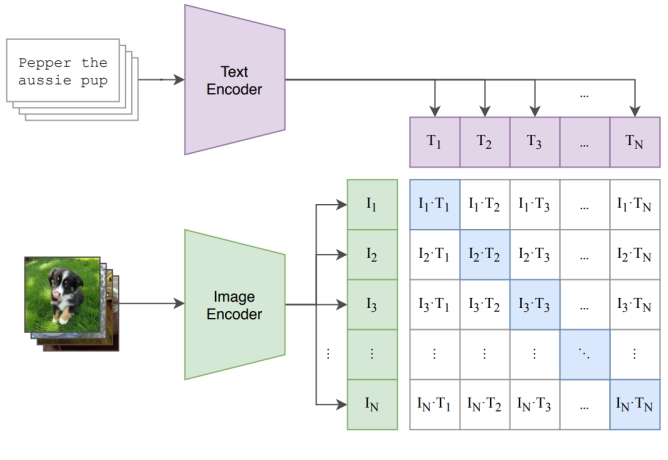

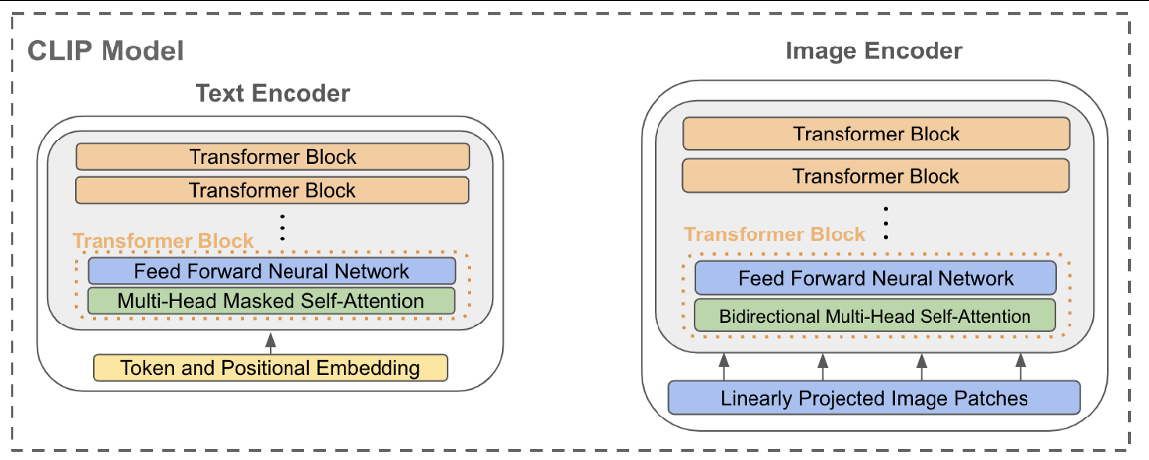

## CLIP Loss Function

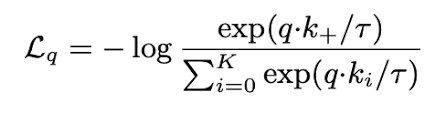

### Import libraries

In [ ]:
import gdown
import os

In [ ]:
!pip install clip

  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6988 sha256=f665e5d6e22c6834d28dd33af386afa339b79e528159c6b1b180edb53a8d6ddc
  Stored in directory: /root/.cache/pip/wheels/7f/5c/e6/2c0fdb453a3569188864b17e9676bea8b3b7e160c037117869
Successfully built clip


In [ ]:
import torch
import clip
from torch import nn
from torch.optim import Adam
from transformers import CLIPProcessor, CLIPModel
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import json
from torch.utils.data import Dataset
from PIL import Image
import torch
from torchvision import transforms

In [ ]:
data_link = 'https://drive.google.com/drive/folders/1lC4YrlZIkunDUyEk5Asqo4NvpZoCHl7s?usp=sharing'
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# After running this, follow the instructions to authenticate.


Mounted at /content/drive


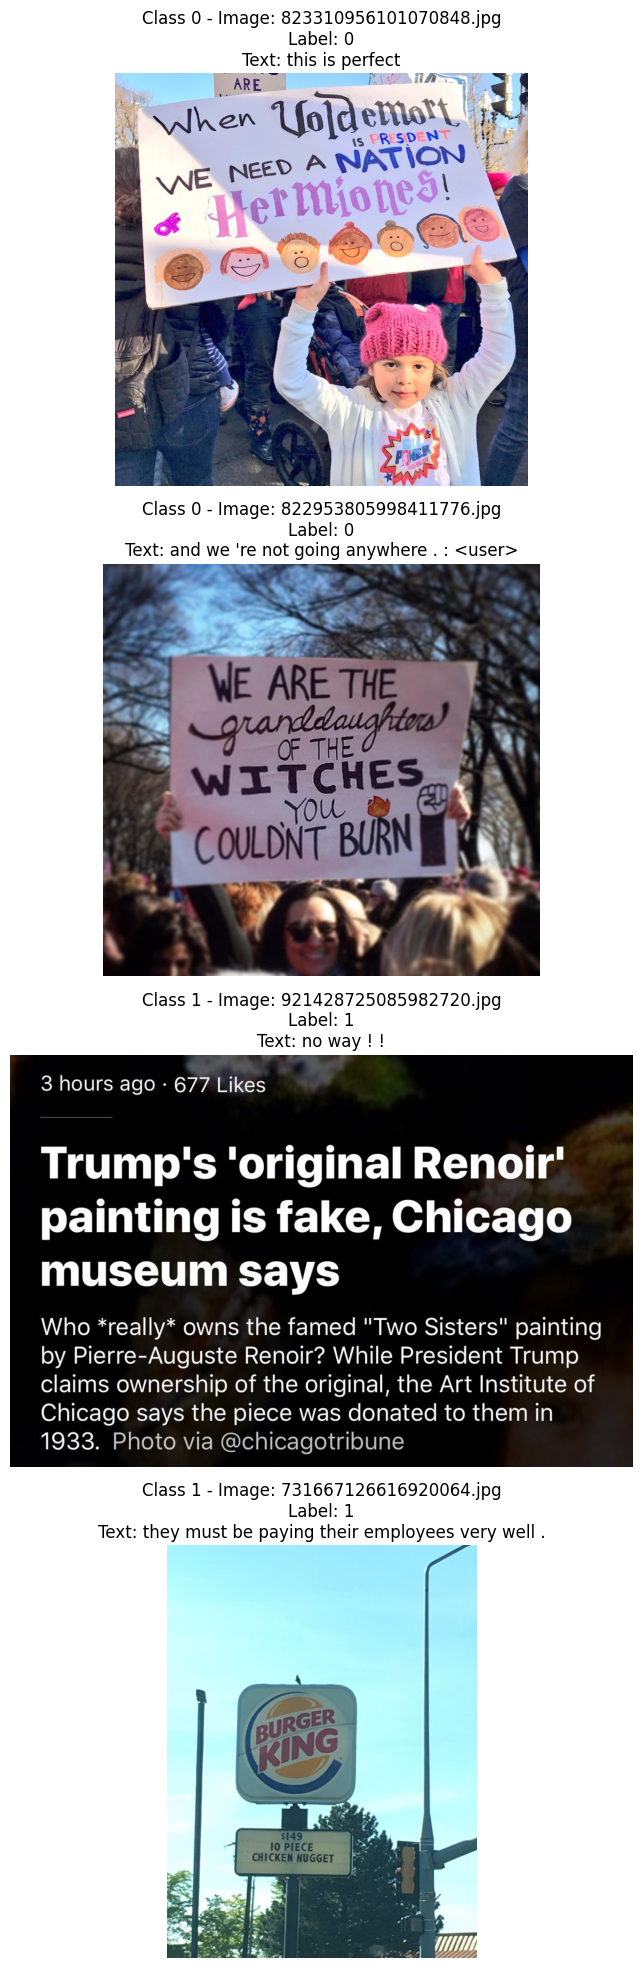

In [ ]:
import json
from PIL import Image
import matplotlib.pyplot as plt

image_path = 'drive/MyDrive/Sarcasm_Data/images/'
json_file = "drive/MyDrive/Sarcasm_Data/data.json"

# Load the JSON data
with open(json_file, 'r') as f:
    data = json.load(f)

# Function to display samples from both classes (0 and 1)
def display_samples(data, image_path, num_samples=5):
    # Extract training data
    train_data = data['train']  # Assuming the JSON structure has 'train' section

    # Separate data by class (0 and 1)
    class_0_samples = [item for item in train_data if item[1] == 0]
    class_1_samples = [item for item in train_data if item[1] == 1]

    # Create a large figure for better visibility
    fig, axes = plt.subplots(num_samples * 2, 1, figsize=(10, 20))  # Increased figure size

    # Display samples from Class 0 (Non-Sarcastic)

    for i in range(min(num_samples, len(class_0_samples))):
        image = image_path + class_0_samples[i][0]
        img = Image.open(image)

        # Display image with larger size
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
        axes[i].set_title(f"Class 0 - Image: {class_0_samples[i][0]}\nLabel: {class_0_samples[i][1]}\nText: {class_0_samples[i][2]}", fontsize=12)

    # Display samples from Class 1 (Sarcastic)

    for i in range(min(num_samples, len(class_1_samples))):
        image = image_path + class_1_samples[i][0]
        img = Image.open(image)

        # Display image with larger size
        axes[i + num_samples].imshow(img)
        axes[i + num_samples].axis('off')  # Hide axes
        axes[i + num_samples].set_title(f"Class 1 - Image: {class_1_samples[i][0]}\nLabel: {class_1_samples[i][1]}\nText: {class_1_samples[i][2]}", fontsize=12)

    # # Add title to the figure
    # fig.suptitle('Multimodal Sarcasm Detection - Class Samples', fontsize=18, weight='bold')

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)  # Adjust top space to fit title
    plt.show()

# Call the function to display 2 samples from each class
display_samples(data, image_path, num_samples=2)



### Define Pytorch Dataset Class

In [ ]:
class SarcasmDataset(Dataset):
    def __init__(self, json_file, transform=None, split=None):
        with open(json_file, 'r') as f:
            data = json.load(f)

        self.texts = []
        self.image_ids = []
        self.labels = []

        # Assuming the JSON has a "train", "val", and "test" keys
        # Each containing a list of [image_id, label, text]
        for entry in data[split]:
            self.image_ids.append(entry[0])
            self.labels.append(entry[1])
            self.texts.append(entry[2])

        self.transform = transform

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        img_path = 'drive/MyDrive/Sarcasm_Data/images/' + self.image_ids[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return text, image, label


### Define Dataloaders

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


json_file = "drive/MyDrive/Sarcasm_Data/data.json"

train_dataset = SarcasmDataset(json_file, transform, split='train')
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = SarcasmDataset(json_file, transform, split='test')
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

### Define CLIP Model

In [ ]:
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [ ]:
class CLIPBinaryClassifier(nn.Module):
    def __init__(self, clip_model):
        super(CLIPBinaryClassifier, self).__init__()
        self.clip_model = clip_model
        self.classifier = nn.Linear(1024, 2)  # Combining 512 (text) + 512 (image)

        # Freeze CLIP model parameters
        # for param in self.clip_model.parameters():
        #     param.requires_grad = False

    def forward(self, input_ids, pixel_values, attention_mask):
        outputs = self.clip_model(input_ids=input_ids, pixel_values=pixel_values, attention_mask=attention_mask)
        text_embeddings = outputs.text_embeds
        image_embeddings = outputs.image_embeds
        combined_embeddings = torch.cat((text_embeddings, image_embeddings), dim=1)
        return self.classifier(combined_embeddings)

model = CLIPBinaryClassifier(model)

### Define loss function and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

CLIPBinaryClassifier(
  (clip_model): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPSdpaAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=5

### Define Train Loop

In [ ]:
num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for texts, images, labels in train_loader:
        optimizer.zero_grad()

        # images= images.to(device)
        # texts = texts.to(device)
        inputs = processor(text=texts, images=images, return_tensors="pt", padding=True, truncation=True, max_length=77)
        #inputs = processor(text=texts, images=images, return_tensors="pt", padding=True,)
        input_ids = inputs["input_ids"].to(device)
        #print(input_ids.shape)
        pixel_values = inputs["pixel_values"].to(device)
        attention_mask = inputs["attention_mask"].to(device)
        labels = labels.to(device)
        #outputs = model(images, texts)
        outputs = model(input_ids=input_ids, pixel_values=pixel_values, attention_mask=attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}")



    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, images, labels in test_loader:
            inputs = processor(text=texts, images=images, return_tensors="pt", padding=True, truncation=True, max_length=77)
            input_ids = inputs["input_ids"].to(device)
            pixel_values = inputs["pixel_values"].to(device)
            attention_mask = inputs["attention_mask"].to(device)
            labels = labels.to(device)

            outputs = model(input_ids=input_ids, pixel_values=pixel_values, attention_mask=attention_mask)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    print('************************************')


It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


Epoch 1/1, Loss: 0.6940
Test Accuracy: 52.80%
************************************


### Save the model

In [ ]:
torch.save(model.state_dict(), "finetuned_clip.pth")


### Load Model for inference

In [ ]:
model.load_state_dict(torch.load("finetuned_clip.pth"))
model.eval()


In [ ]:
import torch
import random
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Assuming the CLIP model class is defined as 'CLIPWithClassifier' and is already trained
# and saved in a file called 'finetuned_clip.pth'

# Define the same image transform as during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Function to load the trained model
def load_model(model_path, device):
    model.load_state_dict(torch.load("finetuned_clip.pth"))
    model.eval()
    model.to(device)
     # Set the model to evaluation mode
    return model

# Function to perform inference and display results
def inference_on_random_samples(model, dataloader, device, num_samples=5):

    # Randomly sample 'num_samples' from the test dataset
    random_samples =

    fig, axes = plt.subplots(num_samples, 1, figsize=(5, 10))

    for i, (text, image, label) in enumerate(random_samples):
        # Move data to the device
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        text = text  # Ensure text is tokenized appropriately before passing to the model

        # Perform inference
        with torch.no_grad():
            output =
        # Get predicted label (assuming the output is logits)
        predicted_label = torch.argmax(output, dim=1).item()

        # Display the image and results
        img = image.squeeze().cpu().permute(1, 2, 0).numpy()  # Convert tensor to image format
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
        axes[i].set_title(f"Original Label: {label.item()} | Predicted: {predicted_label}", fontsize=12)

    plt.tight_layout()
    plt.show()

# Assuming you're using CUDA if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model
model_path = "finetuned_clip.pth"  # Path to your saved model
model = load_model(model_path, device)


inference_on_random_samples(model, test_loader, device, num_samples=5)


In [ ]:
import torch
import random
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor

# Function to perform inference and display results on 5 samples from each class
def inference_on_random_samples(model, dataloader, device, processor, num_samples=5):
    # Separate samples by class (0 and 1)
    class_0_samples = []
    class_1_samples = []

    # Iterate over the data loader and separate samples into class 0 and class 1
    for batch in dataloader:
        text, image, label = batch  # Unpack the batch into text, image, label

        # Ensure text is tokenized using CLIPProcessor
        text_input = processor(text=text, return_tensors="pt", padding=True, truncation=True).input_ids.to(device)  # Tokenize and move text to device
        image = image.to(device)  # Move image to device
        label = label.to(device)  # Move label to device

        # Iterate over each sample in the batch
        for i in range(len(label)):
            if label[i].item() == 0:
                class_0_samples.append((text_input[i], image[i], label[i]))
            else:
                class_1_samples.append((text_input[i], image[i], label[i]))

    # Randomly sample 'num_samples' from each class
    class_0_samples_random = random.sample(class_0_samples, num_samples)
    class_1_samples_random = random.sample(class_1_samples, num_samples)

    # Combine the samples from both classes
    random_samples = class_0_samples_random + class_1_samples_random

    # Create a subplot to display the images
    fig, axes = plt.subplots(num_samples * 2, 1, figsize=(5, 10))

    # Process each sample
    for i, (text_input, image, label) in enumerate(random_samples):
        # Perform inference
        with torch.no_grad():
            output = model(input_ids=text_input.unsqueeze(0), pixel_values=image.unsqueeze(0))  # Add batch dimension

        # Get predicted label (assuming the output is logits)
        predicted_label = torch.argmax(output.logits, dim=1).item()  # Get predicted label, assuming output is logits

        # Ensure label is a scalar
        label = label.item()

        # Display the image and results
        img = image.squeeze().cpu().permute(1, 2, 0).numpy()  # Convert tensor to image format
        axes[i].imshow(img)
        axes[i].axis('off')  # Hide axes
        axes[i].set_title(f"Original Label: {label} | Predicted: {predicted_label}", fontsize=12)

    plt.tight_layout()
    plt.show()

# Assuming you're using CUDA if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the CLIPProcessor
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load the model
model_path = "finetuned_clip.pth"  # Path to your saved model
model = load_model(model_path, device)

# Assuming you have a validation DataLoader ready
# Replace 'test_loader' with your actual DataLoader for the validation set
inference_on_random_samples(model, test_loader, device, processor, num_samples=5)
